# Práctica 03. Análisis Estadistico de señales

### Estudiante 1: Valentina García Obando Cc 1000539432
### Estudiante 2: Luis Eduardo Grajales Cc 1003293560

 Funciones en Python:

*   mean: Calcula el promedio de un conjunto de datos (np.mean())
*   var: Calcula la varianza de un conjunto de datos, es decir mide cuánto se dispersan los datos respecto a la media.
*   std: Calcula la desviación estandar (raiz cuadrada de la varianza) y arroja valores más faciles de interpretar que la varianza

In [33]:
!pip install pandas
#Exportar los datos
!pip install scipy #isntalar la libreria scipy que permitirá leer los archivos .mat


ERROR: Invalid requirement: '#isntalar': Expected package name at the start of dependency specifier
    #isntalar
    ^


In [34]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks #ayudará más adelnate a buscar picos de señales
import pandas as pd
from scipy.stats import shapiro #Prueba de Shapiro
from scipy.stats import levene #Prueba de homocedasticidad
from scipy.stats import mannwhitneyu #Prueba de Mann Whitney U
from statsmodels.tsa.stattools import adfuller #Prueba de Augmented Dickey-Fuller

### Exportar los datos de interes para ECG

In [35]:
# Lectura del archivo .mat que contiene las señales registradas
mat = sio.loadmat("signals.mat")

# Mostrar las variables disponibles dentro del archivo
# Esto permite identificar cuáles señales se pueden utilizar
print(mat.keys())

# Seleccionar la señal de ECG registrada
raw = mat['ECG_asRecording']

# Verificar las dimensiones del arreglo cargado
print(raw.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
(1, 30720)


Se utilizará la función np.squeeze, la cual permite eliminar dimensiones innecesarias del arreglo. En este caso, se emplea para transformar el vector bidimensional observado en la señal ECG_asRecording en un arreglo unidimensional. Este procedimiento facilita el manejo de la señal y permite realizar posteriormente las operaciones matemáticas necesarias a lo largo del análisis.

In [36]:
# Extraer las variables necesarias para el análisis de la señal ECG
fs = float(np.squeeze(mat['Fs']))  # obtener la frecuencia de muestreo

ECG_original = np.squeeze(mat['ECG_asRecording'])   # señal ECG registrada sin procesar
ECG_filtrada = np.squeeze(mat['ECG_filtered'])      # señal ECG después del filtrado

# Mostrar información básica de las señales
print("Frecuencia de muestreo:", fs, "Hz")
print("Dimensiones de la señal ECG original:", ECG_original.shape)
print("Dimensiones de la señal ECG filtrada:", ECG_filtrada.shape)

Frecuencia de muestreo: 1024.0 Hz
Dimensiones de la señal ECG original: (30720,)
Dimensiones de la señal ECG filtrada: (30720,)


Una vez obtenido un arreglo con dimensiones (30720,), se facilita la aplicación de las diferentes operaciones y procedimientos necesarios para el análisis durante el desarrollo del taller.

**Implemente una función que permita calcular el valor cuadrático medio (RMS) de una señal. El valor RMS se define en forma discreta con N número de muestras, como:**

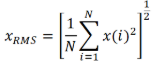

In [37]:
def calcular_RMS(signal):

    # Convertir la entrada a un arreglo de NumPy para asegurar compatibilidad
    signal = np.asarray(signal)

    # Número total de muestras de la señal
    N = len(signal)

    # Aplicación de la fórmula del valor cuadrático medio (RMS)
    rms = np.sqrt(np.sum(signal**2) / N)

    return rms

**A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo.**

In [38]:
# número de muestras en cada señal
n_original = len(ECG_original)      # muestras de la señal original
n_filtrada = len(ECG_filtrada)      # muestras de la señal filtrada

# cálculo del tiempo total de duración
duracion_original = n_original / fs
duracion_filtrada = n_filtrada / fs

print("Duración señal original:", duracion_original, "s")
print("Duración señal filtrada:", duracion_filtrada, "s")

# generación del vector de tiempo asociado a las muestras
t = np.arange(n_filtrada) / fs

print(t)

Duración señal original: 30.0 s
Duración señal filtrada: 30.0 s
[0.00000000e+00 9.76562500e-04 1.95312500e-03 ... 2.99970703e+01
 2.99980469e+01 2.99990234e+01]


**Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.**

Se realiza un recorte en la señal para visualizar solo el comportamiento de las señales en los dos primeros segundos.

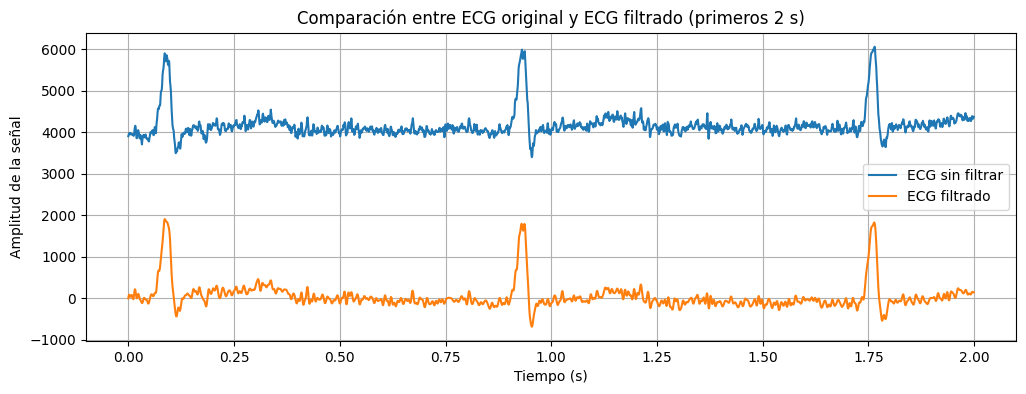

In [39]:
# seleccionar únicamente los primeros 2 segundos de la señal
muestras_2s = int(2 * fs)   # cantidad de muestras correspondientes a 2 s

# recortar las señales para visualizar solo ese intervalo
t_2s = t[:muestras_2s]
ECG_original_2s = ECG_original[:muestras_2s]
ECG_filtrado_2s = ECG_filtrada[:muestras_2s]

# graficar ambas señales para comparar su comportamiento
plt.figure(figsize=(12,4))

plt.plot(t_2s, ECG_original_2s, label="ECG sin filtrar")
plt.plot(t_2s, ECG_filtrado_2s, label="ECG filtrado")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud de la señal")
plt.title("Comparación entre ECG original y ECG filtrado (primeros 2 s)")
plt.grid(True)
plt.legend()

plt.show()

En la señal original se pueden identificar claramente los complejos QRS, los cuales aparecen como picos pronunciados asociados a cada latido cardíaco. La amplitud de estos picos se encuentra aproximadamente entre 4000 y 6000 unidades. Por otro lado, la señal filtrada se observa centrada alrededor de cero, lo que indica que el filtrado ha reducido el desplazamiento de la línea base presente en la señal cruda. Esto se debe a que el filtro aplicado atenúa principalmente las componentes de muy baja frecuencia, responsables de este desplazamiento. Además, el proceso de filtrado contribuye a disminuir el ruido de alta frecuencia y otras interferencias como la actividad muscular o el ruido de la red eléctrica. De esta forma, se conservan las frecuencias características del ECG, que generalmente se encuentran en el rango de 0.5 a 40 Hz para aplicaciones clínicas. A pesar del filtrado, los complejos QRS continúan siendo claramente identificables, lo que permite determinar los latidos. En el intervalo analizado de 2 segundos se observan tres picos principales, lo cual es compatible con una frecuencia cardíaca dentro de valores normales. Extrapolando este comportamiento a intervalos de mayor duración, por ejemplo un minuto, se podría estimar una frecuencia cercana a 90 latidos por minuto.[1]

**Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.**

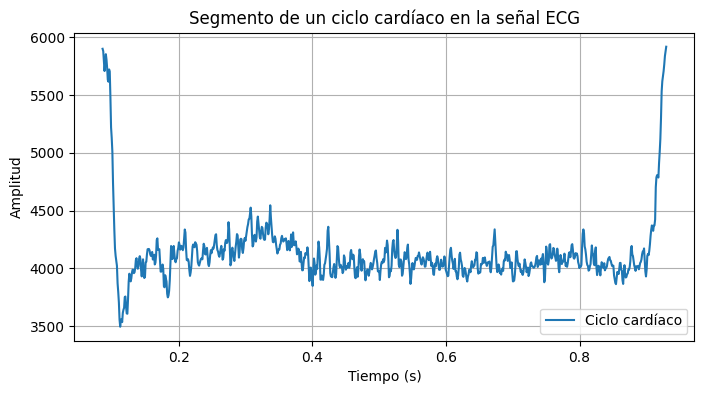

Promedio del ciclo cardiaco: 4131.136266878161
Varianza del ciclo cardiaco: 93646.2220564969
Desviación estándar del ciclo cardiaco: 306.01670225086883
Valor RMS del ciclo cardiaco: 4142.454957820607


In [40]:
# detectar los picos en la señal ECG original
indices_picos, _ = find_peaks(ECG_original, distance=int(0.6 * fs))  
# se define una distancia mínima entre picos para evitar detectar múltiples puntos del mismo latido

# seleccionar un ciclo cardiaco entre dos picos consecutivos
ciclo_ECG = ECG_original[indices_picos[0]:indices_picos[1]]
t_ciclo = t[indices_picos[0]:indices_picos[1]]

# graficar el ciclo seleccionado
plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_ECG, label="Ciclo cardíaco")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Segmento de un ciclo cardíaco en la señal ECG")
plt.grid(True)
plt.legend()

plt.show()

# cálculo de estadísticas básicas del ciclo cardiaco seleccionado
promedio_ciclo = np.mean(ciclo_ECG)
var_ciclo = np.var(ciclo_ECG)
std_ciclo = np.std(ciclo_ECG)
valor_rms = calcular_RMS(ciclo_ECG)

print("Promedio del ciclo cardiaco:", promedio_ciclo)
print("Varianza del ciclo cardiaco:", var_ciclo)
print("Desviación estándar del ciclo cardiaco:", std_ciclo)
print("Valor RMS del ciclo cardiaco:", valor_rms)

**Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados obtenidos en el ítem anterior.**

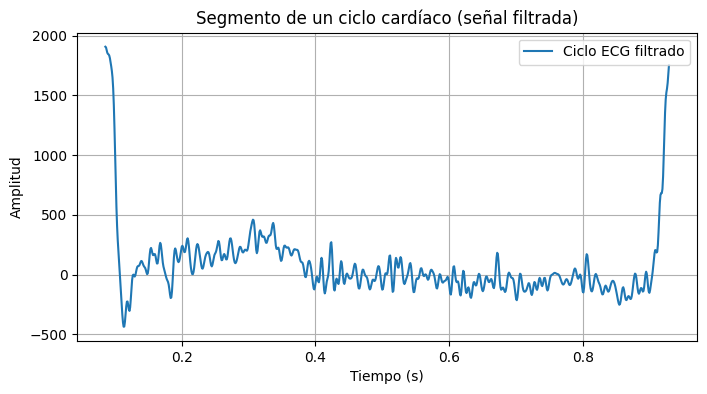

Promedio del ciclo filtrado: 74.00995782055861
Varianza del ciclo filtrado: 96684.31488232457
Desviación estándar del ciclo filtrado: 310.94101511753735
Valor RMS del ciclo filtrado: 319.62757818893766


In [41]:
# detección de picos en la señal ECG filtrada
indices_picos_f, _ = find_peaks(ECG_filtrada, distance=int(0.6 * fs))
# se fija una distancia mínima entre picos para evitar múltiples detecciones en un mismo latido

# extracción de un ciclo cardíaco entre dos picos consecutivos
ciclo_filtrado = ECG_filtrada[indices_picos_f[0]:indices_picos_f[1]]
t_ciclo_filtrado = t[indices_picos_f[0]:indices_picos_f[1]]

# gráfica del ciclo seleccionado
plt.figure(figsize=(8,4))
plt.plot(t_ciclo_filtrado, ciclo_filtrado, label="Ciclo ECG filtrado")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Segmento de un ciclo cardíaco (señal filtrada)")
plt.grid(True)
plt.legend()

plt.show()

# cálculo de estadísticas del ciclo obtenido de la señal filtrada
promedio_filtrado = np.mean(ciclo_filtrado)
varianza_filtrado = np.var(ciclo_filtrado)
std_filtrado = np.std(ciclo_filtrado)
rms_filtrado = calcular_RMS(ciclo_filtrado)

print("Promedio del ciclo filtrado:", promedio_filtrado)
print("Varianza del ciclo filtrado:", varianza_filtrado)
print("Desviación estándar del ciclo filtrado:", std_filtrado)
print("Valor RMS del ciclo filtrado:", rms_filtrado)

En la señal original, el valor promedio del ciclo cardíaco se encuentra aproximadamente en 4131, mientras que en la señal filtrada disminuye considerablemente hasta un valor cercano a 74. Este cambio se relaciona con el efecto del filtro aplicado, el cual elimina las componentes de muy baja frecuencia y corrige el desplazamiento de la línea base, provocando que la señal quede centrada alrededor de cero.

Por otro lado, la varianza presenta valores muy similares en ambos casos, alrededor de 93 646 para la señal original y 96 684 para la señal filtrada. Esto sugiere que la dispersión de los datos respecto a la media se mantiene prácticamente igual, lo cual indica que el filtrado no afecta de manera significativa la variabilidad característica del ciclo cardíaco.

De forma similar, la desviación estándar también muestra valores cercanos entre ambas señales (aproximadamente 306 en la señal original y 311 en la filtrada). Este resultado confirma que la amplitud relativa de los complejos QRS y la variabilidad general de la señal se conservan después del proceso de filtrado.

En cuanto al valor RMS, se observa una diferencia más notable: mientras que en la señal original el valor es cercano a 4142, en la señal filtrada disminuye hasta aproximadamente 320. Esta reducción ocurre porque el filtrado elimina el desplazamiento de la señal y la centra alrededor del eje de referencia, lo que reduce su magnitud promedio.

En conjunto, el análisis estadístico permite verificar que el proceso de filtrado mejora la estabilidad de la señal sin modificar las características fisiológicas principales del ECG, como la presencia de los complejos QRS o la amplitud relativa entre los picos de la señal. Esto resulta fundamental para realizar análisis clínicos posteriores con mayor confiabilidad.


**Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?**

Para el análisis de los ciclos cardíacos se utilizó la función find_peaks, la cual permite identificar los máximos locales presentes en una señal. En este caso, se empleó el parámetro distance, que define la separación mínima entre picos consecutivos en términos de número de muestras, teniendo en cuenta la frecuencia de muestreo de la señal. Se seleccionó un valor equivalente a 0.6 segundos, ya que este intervalo corresponde aproximadamente al tiempo entre latidos para una frecuencia cardíaca cercana a 100 latidos por minuto (60 / 0.6). De esta manera, se garantiza que los picos detectados correspondan a complejos R de distintos ciclos cardíacos y no a múltiples puntos dentro de un mismo latido. Este criterio permite que el algoritmo identifique de forma adecuada los picos R bajo condiciones fisiológicas normales [1].

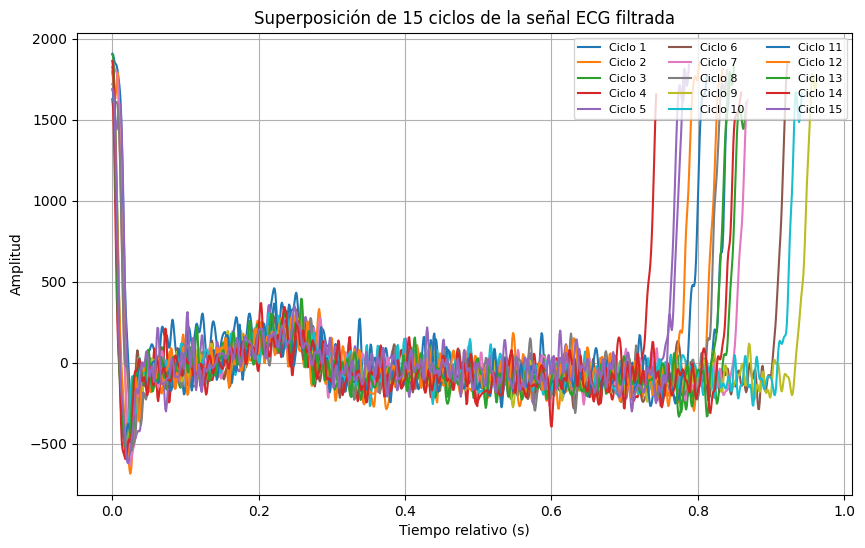

    Ciclo  Promedio  Varianza  Desv.Std    RMS
0       1      74.0   96684.3     310.9  319.6
1       2      -1.5  104790.5     323.7  323.7
2       3     -10.4   82451.3     287.1  287.3
3       4     -21.0   46839.0     216.4  217.4
4       5      40.9  114850.0     338.9  341.4
5       6     -27.9   58147.6     241.1  242.8
6       7       0.4   77707.3     278.8  278.8
7       8      21.4  100268.2     316.7  317.4
8       9     -10.2   71785.0     267.9  268.1
9      10       8.8   68481.1     261.7  261.8
10     11      -8.9   76088.4     275.8  276.0
11     12      13.2   93862.7     306.4  306.7
12     13      -4.2   87951.5     296.6  296.6
13     14     -15.0   77022.1     277.5  277.9
14     15      27.1   89636.9     299.4  300.6


In [42]:
# Identificar los picos R en la señal ECG filtrada
indices_R, _ = find_peaks(ECG_filtrada, distance=int(0.6 * fs))  # separación mínima de 0.6 s

# Número de ciclos cardíacos a analizar
n_ciclos = 15

segmentos = []   # lista donde se almacenará cada ciclo
promedios, vars_, stds, valores_rms = [], [], [], []

for k in range(n_ciclos):
    
    # Extraer el segmento entre dos picos consecutivos
    segmento = ECG_filtrada[indices_R[k]:indices_R[k+1]]
    segmentos.append(segmento)

    # Calcular estadísticas de cada ciclo
    promedios.append(np.mean(segmento))
    vars_.append(np.var(segmento))
    stds.append(np.std(segmento))
    valores_rms.append(calcular_RMS(segmento))

plt.figure(figsize=(10,6))

for k, segmento in enumerate(segmentos):
    
    # generar eje de tiempo relativo para cada ciclo
    t_rel = np.linspace(0, len(segmento)/fs, len(segmento))
    
    plt.plot(t_rel, segmento, label=f"Ciclo {k+1}")

plt.xlabel("Tiempo relativo (s)")
plt.ylabel("Amplitud")
plt.title("Superposición de 15 ciclos de la señal ECG filtrada")
plt.legend(loc="upper right", fontsize=8, ncol=3)
plt.grid(True)

plt.show()

# organizar los resultados en una tabla para visualización
resultados = pd.DataFrame({
    "Ciclo": range(1, 16),
    "Promedio": promedios,
    "Varianza": vars_,
    "Desv.Std": stds,
    "RMS": valores_rms
})

# redondear valores para facilitar la lectura
resultados = resultados.round(1)

print(resultados)

En el caso de un electrocardiograma, se considera que la señal presenta un comportamiento estacionario cuando no se observan cambios importantes en su amplitud o forma entre diferentes ciclos cardíacos. Esto implica que el patrón de la señal se mantiene relativamente constante en el tiempo, lo cual suele asociarse con un funcionamiento cardíaco regular y saludable [2]. Este comportamiento puede evaluarse a partir de diferentes medidas estadísticas.

Media: Los valores del promedio se encuentran aproximadamente entre −27 y +74. Esto indica que, después del filtrado, la señal se encuentra centrada alrededor de cero, lo cual sugiere que el filtro eliminó en gran parte el desplazamiento de la línea base. Sin embargo, aún se observan pequeñas variaciones entre ciclos, ya que algunos presentan valores positivos y otros negativos.

Varianza: La varianza se mantiene en un rango aproximado entre 46 000 y 114 000. Estos valores muestran que la variabilidad de la señal entre ciclos no cambia de manera drástica, aunque sí existen ligeras diferencias entre algunos latidos.

Desviación estándar: Esta medida permite evaluar la dispersión de la amplitud de la señal. En la tabla se observa que sus valores no presentan variaciones muy grandes entre ciclos, lo cual sugiere que la amplitud de los complejos cardíacos se mantiene relativamente constante.

RMS: El valor RMS, que representa una medida de la magnitud efectiva de la señal, tampoco muestra cambios extremos entre ciclos. Esto indica que la energía de la señal se conserva de forma similar a lo largo de los distintos latidos analizados.

A partir de estos resultados estadísticos se puede inferir que la señal de ECG analizada presenta características cercanas a un comportamiento estacionario. Aunque el promedio muestra algunas fluctuaciones, los valores permanecen cercanos a cero, mientras que la varianza y la desviación estándar se mantienen dentro de rangos relativamente estables, sin cambios abruptos entre ciclos.

Además, la gráfica de los 15 ciclos de la señal ECG filtrada superpuestos permite observar con mayor claridad este comportamiento. Al alinearse los ciclos respecto al pico R, se evidencia que la morfología de la señal (ondas P, complejo QRS y onda T) es muy similar entre los diferentes latidos, lo que indica un patrón repetitivo y estable. De igual forma, no se observan diferencias significativas en la amplitud de los complejos QRS ni de las ondas T, lo que sugiere que la energía de la señal se mantiene constante de un ciclo a otro. Finalmente, el intervalo temporal entre ciclos también se conserva de forma regular, sin cambios bruscos en su duración.

**Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).**

Se van a seleccionar ciclos que esten alejados entre ellos para asi evaluar el compotamiento de ciclos no contiguos.

In [43]:
# Seleccionar dos ciclos cardíacos para realizar las pruebas estadísticas
ciclo_A = segmentos[3]   # corresponde al ciclo número 4
print("Dimensión del ciclo A:", ciclo_A.shape)

ciclo_B = segmentos[4]   # corresponde al ciclo número 5
print("Dimensión del ciclo B:", ciclo_B.shape)

Dimensión del ciclo A: (761,)
Dimensión del ciclo B: (802,)


La prueba t de Student es una prueba estadística que analiza si dos muestras proceden de poblaciones que cuentan con la misma media. Cuantifica la diferencia entre la media de las dos muestras y, teniendo en cuenta su varianza, estima la probabilidad de que se obtenga una diferencia igual o mayor a la que se observa si se establece que la hipótesis nula establece que las medias poblacionales son iguales. Esa probabilidad se conoce como p-value. Cuando se habla de p-value se tiene que definir un rango en donde se establece si se rechaza o no la hipótesis nula. Cuando p-value es mayor que cierto límite determinado, se dice que no se rechaza la hipótesis nula; si ese valor es menor, se considera que la hipótesis nula se rechaza [3].

***Hipótesis nula***: No hay diferencias entre los ciclos elegidos, es decir que las medidas poblacionales son iguales.

***Hipótesis alternativa***: Sí existe una diferencia entre las medidas de los ciclos.

Las condiciones de un t de Student son:

- Independencia: Observaciones independientes entre ellas.

- Normalidad: Las muestras se tienen que distribuir de forma normal.

- Igualdad de varianza (homocedasticidad): La varianza de ambas poblaciones debe ser igual.

Se va a asumir un valor para establecer la estadística del problema:

- p > 0.05: las varianzas son iguales y se asume normalidad.

- p <= 0.05: las varianzas son diferentes y los datos no son normales.

In [44]:
from scipy.stats import shapiro

# Evaluar si los ciclos siguen una distribución normal
stat_A, p_val_A = shapiro(ciclo_A)
stat_B, p_val_B = shapiro(ciclo_B)

print(f"p-value normalidad ciclo A: {p_val_A}")
print(f"p-value normalidad ciclo B: {p_val_B}")

p-value normalidad ciclo A: 2.5586738564090947e-36
p-value normalidad ciclo B: 1.6230300122465054e-40


Para evaluar si los ciclos seleccionados siguen una distribución normal, se aplicó la prueba de Shapiro–Wilk. Los resultados obtenidos mostraron valores de p extremadamente bajos (2.55×10⁻³⁶ y 1.62×10⁻⁴⁰), los cuales son considerablemente menores que el nivel de significancia establecido de 0.05. Debido a esto, se rechaza la hipótesis nula de normalidad, lo que indica que los datos correspondientes a los ciclos analizados no siguen una distribución normal.

La prueba de Shapiro–Wilk fue seleccionada debido a que es especialmente adecuada para muestras pequeñas, como en el caso de los ciclos individuales de una señal ECG. Además, esta prueba presenta una alta sensibilidad para detectar desviaciones respecto a la normalidad, lo que la convierte en una herramienta útil para evaluar la distribución de los datos antes de aplicar pruebas estadísticas paramétricas.

In [45]:
from scipy.stats import levene

# Evaluar igualdad de varianzas entre los dos ciclos
stat_levene, p_val_levene = levene(ciclo_A, ciclo_B)

print(f"p-value prueba de Levene: {p_val_levene}")

p-value prueba de Levene: 0.0004643053549308521


Para evaluar si las varianzas de los ciclos seleccionados eran equivalentes, se aplicó la prueba de Levene, la cual permite determinar si dos muestras presentan una dispersión similar alrededor de su media. El resultado obtenido fue un valor p de aproximadamente 0.000464, valor que es considerablemente menor que el nivel de significancia establecido de 0.05. Debido a esto, se rechaza la hipótesis nula de igualdad de varianzas, lo que indica que los ciclos analizados no presentan homocedasticidad.

Este resultado sugiere que la variabilidad de los datos no es la misma en ambos ciclos cardíacos. Además, confirma que no se cumplen completamente las condiciones necesarias para aplicar una prueba t de Student, ya que esta prueba paramétrica requiere que las muestras tengan varianzas similares.

In [46]:
from scipy.stats import mannwhitneyu

# Aplicar prueba no paramétrica para comparar los ciclos
stat_U, p_val_U = mannwhitneyu(ciclo_A, ciclo_B)

print(f"p-value prueba Mann-Whitney: {p_val_U}")

p-value prueba Mann-Whitney: 8.421413997601233e-05


Debido a que no se cumplieron las condiciones necesarias para aplicar una prueba t de Student —ya que la prueba de Shapiro-Wilk indicó ausencia de normalidad y la prueba de Levene evidenció desigualdad de varianzas— se decidió emplear una prueba no paramétrica. En este caso se utilizó la prueba de Mann-Whitney, la cual permite comparar dos muestras independientes sin asumir una distribución normal de los datos.

El resultado de la prueba arrojó un valor p de aproximadamente 8.42 × 10⁻⁵, valor significativamente menor que el nivel de significancia establecido de 0.05. Por lo tanto, se rechaza la hipótesis nula de igualdad entre las distribuciones de los ciclos analizados. Este resultado indica que existe una diferencia estadísticamente significativa entre ambos ciclos cardíacos, lo que sugiere que sus características estadísticas no son equivalentes.


Al rechazarse todas las pruebas realizadas se procede hacer la prueba de Dickey - Fuller.

**Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad)**

In [47]:
# Unir los dos ciclos seleccionados para analizar la serie completa
serie_ecg = np.concatenate([ciclo_A, ciclo_B])

from statsmodels.tsa.stattools import adfuller

# Aplicar la prueba de Dickey-Fuller aumentada
resultado_adf = adfuller(serie_ecg)

print("Estadístico ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])
print("Valores críticos:", resultado_adf[4])

Estadístico ADF: -3.1607048568745704
p-value: 0.022374915738300846
Valores críticos: {'1%': np.float64(-3.4345923608042512), '5%': np.float64(-2.8634137428910185), '10%': np.float64(-2.567767551360439)}


La prueba de Dickey–Fuller aumentada (ADF) se utilizó para evaluar la estacionariedad de la señal construida a partir de los ciclos analizados. El resultado obtenido mostró un estadístico ADF cercano a −3.16 y un p-valor aproximado de 0.022. Dado que este valor es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula de presencia de raíz unitaria. Esto indica que la serie analizada puede considerarse estacionaria.

Al comparar el estadístico ADF con los valores críticos reportados por la prueba, se observa que es menor que el valor crítico correspondiente al 5% (−2.86), aunque no alcanza el nivel más estricto del 1% (−3.43). Esto sugiere que existe evidencia suficiente de estacionariedad bajo un nivel de significancia del 5%.

En consecuencia, se puede concluir que la señal presenta un comportamiento aproximadamente estacionario dentro del intervalo analizado. Este resultado es coherente con el comportamiento observado en la superposición de los ciclos cardíacos, donde la morfología de la señal se mantiene relativamente constante entre latidos.

In [48]:
# Aplicar la prueba ADF considerando los 15 ciclos obtenidos
serie_completa = np.concatenate(segmentos)

resultado_adf_total = adfuller(serie_completa)

print("Estadístico ADF:", resultado_adf_total[0])
print("p-value:", resultado_adf_total[1])
print("Valores críticos:", resultado_adf_total[4])

Estadístico ADF: -7.824143865169806
p-value: 6.549790518299567e-12
Valores críticos: {'1%': np.float64(-3.4308529676486708), '5%': np.float64(-2.8617622874368585), '10%': np.float64(-2.566888318671982)}


De manera similar al análisis realizado previamente, esta prueba permite evaluar el comportamiento de la señal considerando los 15 ciclos cardíacos analizados. A partir de los resultados obtenidos se observa que el estadístico ADF presenta un valor significativamente bajo y el p-valor es mucho menor que el nivel de significancia de 0.05, lo que permite rechazar la hipótesis nula de presencia de raíz unitaria. En consecuencia, se puede considerar que la señal conformada por los 15 ciclos presenta un comportamiento estacionario.

## Conclusiones:

El proceso de preprocesamiento mediante un filtro pasa-banda permitió reducir el desplazamiento de la línea base y eliminar parte del ruido de alta frecuencia presente en la señal original. Este filtrado conservó las componentes principales del ECG, especialmente los complejos QRS, lo que facilita la identificación de los ciclos cardíacos sin afectar la información fisiológica relevante. Tanto la inspección gráfica como el análisis estadístico permitieron confirmar la efectividad del filtrado.

El cálculo de parámetros estadísticos como la media, la varianza, la desviación estándar y el valor RMS mostró que las características de los ciclos cardíacos se mantienen relativamente estables entre sí. Las pruebas de normalidad (Shapiro-Wilk) y de igualdad de varianzas (Levene) indicaron que no se cumplen las condiciones necesarias para aplicar una prueba t de Student, por lo que fue necesario utilizar métodos no paramétricos como la prueba de Mann-Whitney, la cual evidenció diferencias estadísticas entre algunos ciclos analizados.

Finalmente, la prueba de Dickey-Fuller aumentada aplicada inicialmente a un ciclo mostró indicios de estacionariedad, mientras que al extender el análisis a los 15 ciclos el estadístico obtenido fue aún más significativo. Esto permite concluir con mayor certeza que la señal ECG analizada presenta un comportamiento estacionario en el intervalo estudiado, lo cual es coherente con lo esperado para un registro correspondiente a un sujeto con ritmo cardíaco estable.

## Referencias

[1] Matematizame, “La desviación estándar en estadística: impacto y calidad de análisis”, Matematizame. [En línea]. Disponible: https://matematizame.com/la-desviacion-estandar-en-estadistica-impacto-y-calidad-de-analisis/?damemas_lectura=1

[2] J. Amat Rodrigo, “T-test con Python”, CienciaDeDatos.net, Dic. 2021. [En línea]. Disponible: https://cienciadedatos.net/documentos/pystats10-t-test-python.html

[3] J. Amat Rodrigo, “T-test con Python”, CienciaDeDatos.net, Dic. 2021. [En línea]. Disponible: https://cienciadedatos.net/documentos/pystats10-t-test-python.html
